# **Eksoplanet**

### Knjižnice in osnove

In [2]:
%matplotlib inline
from astropy.io import fits # modul za delo s fits posnetki
import matplotlib.pyplot as plt # modul za risanje grafov
import numpy as np # modul za numerične operacije
import astroalign # modul za poravnavo astronomskih posnetkov
import glob # Modul za brskanje po mapah
import os
from astropy.time import Time
import matplotlib.dates as mdates
import batman


from photutils.detection import DAOStarFinder
import matplotlib

from scipy.optimize import curve_fit

In [3]:

folder =  os.path.join(os.path.abspath(''), "Data", "Eksoplanet")

c_map = {}
for i in range(26):
  if i != 0:
    c_map[i] = matplotlib.colors.to_hex(matplotlib.colormaps.get_cmap('RdYlGn')(i/25))
  else:
    c_map["TOI-2046 b"] = "#360202" #matplotlib.colors.to_hex(matplotlib.colormaps.get_cmap('RdYlGn')(0))

#starts se pridobi kasnjeje v kodi, ampak je uveden tukaj za hitrejšo ponovno izvajanje
                        #x_pos                  y_pos                   Gmag          apeture inner_r outer_ring
stars=  { "TOI-2046 b": [1774.7176400821181,    1332.1728502524682,     None     ,    (5.0,   10.0,   18.0)],  #TOI-2046 b
                     1:	[2268.400897297504,	    809.804581019461,       14.404225,    (5.0,   10.0,   18.0)],  #1
                     2:	[2011.94240282978,	    846.5737559618958,      14.018103,    (5.0,   10.0,   18.0)],  #2
                     3:	[1996.4086949644739,	  867.1066407168496,      12.292048,    (5.0,   10.0,   18.0)],  #3
                     4:	[1534.2211561715083,	  945.2452971992026,      14.533058,    (5.0,   10.0,   18.0)],  #4
                     5:	[2162.4881081278454,	  980.9641654834039,      10.465836,    (5.0,   10.0,   18.0)],  #5
                     6:	[1896.7130285961152,	  984.7321500490623,      13.747992,    (5.0,   10.0,   18.0)],  #6
                     7:	[1436.2709501132688,	  1022.0026325638815,     14.107033,    (5.0,   10.0,   18.0)],  #7
                     8:	[2095.917107611144,	    1035.5918083101092,     14.118480,    (5.0,   10.0,   18.0)],  #8
                     9:	[1172.3288420290974,	  1073.0988971069478,     12.163483,    (5.0,   10.0,   18.0)],  #9
                    10:	[1723.9292438964942,	  1126.0610907952505,     14.066322,    (5.0,   10.0,   18.0)],  #10
                    11:	[1742.3488306240718,	  1129.6714222962487,     14.025434,    (5.0,   10.0,   18.0)],  #11
                    12:	[1184.567464589557,	    1130.9679957801018,     13.032532,    (5.0,   10.0,   18.0)],  #12
                    13:	[1500.4796001315049,	  1147.8989553398603,     11.095935,    (5.0,   10.0,   18.0)],  #13
                    14:	[1139.874255773819,	    1222.3336413586367,     14.167420,    (5.0,   10.0,   18.0)],  #14
                    15:	[1425.882634565117,	    1248.09847458422,       13.285791,    (5.0,   10.0,   18.0)],  #15
                    16:	[1540.3764464300534,	  1264.5071189989346,     11.762952,    (5.0,   10.0,   18.0)],  #16
                    17:	[1978.0349468141367,	  1272.817853767221,      12.333929,    (5.0,   10.0,   18.0)],  #17
                    18:	[1645.909258006847,	    1309.9908648167593,     12.484468,    (5.0,   10.0,   18.0)],  #18
                    19:	[1919.2404394756293,	  1334.5161223553646,     11.337429,    (5.0,   10.0,   18.0)],  #19
                    20:	[1112.954246795195,	    1345.294256719308,      14.299550,    (5.0,   10.0,   18.0)],  #20
                    21:	[2032.8635578981944,	  1400.045418256521,      6.790042 ,    (40.0,  50.0,   60.0)],  #21
                    22:	[1952.0421356237325,	  1403.8094834694004,     14.355612,    (5.0,   10.0,   18.0)],  #22
                    23:	[1518.1733771681975,	  1438.3589496256127,     13.583919,    (5.0,   10.0,   18.0)],  #23
                    24:	[1566.3348765286833,	  1464.945480481325,      12.524779,    (5.0,   10.0,   18.0)],  #24
                    25:	[1799.8779136054593,	  1479.4098995581642,     13.100456,    (5.0,   10.0,   18.0)]}  #25


### Osnova: BIAS, DARK, FLAT 

Združevanje in pridobivanje "masterfiles" za:  
&emsp;  - BIAS  
&emsp;  - DARK  
&emsp;  - FLAT  

In [ ]:
#Source folder
folder =  os.path.join(os.path.abspath(''), "Data", "Eksoplanet")

##Oblika projekta
'''
  Main folder/
  ├── Data/Eksoplanet
  |         ├── BIAS/
  |         │   ├── ... .fits
  |         │   └── masterbias.fits (ustvari program tukaj)
  |         ├── DARK/
  |         │   ├── ... .fits
  |         │   └── masterdark.fits (ustvari program tukaj)
  |         ├── FLAT/
  |         │   ├── ... .fits
  |         │   └── masterflat.fits (ustvari program tukaj)
  |         ├── LIGHT/ (podatki čez noč, slike)
  |         └── SNAPSHOT/ (za zdaj nimam pojma kaj je)
  │
  └── astronomija_master.ipynb (To bereš zdaj)
'''


## BIAS
# Seznam vseh bias posnetkov
biases =  glob.glob(os.path.join(folder, "BIAS","V*.fits"))

# Odprimo vse bias posnetke
biases_data = []
for bias in biases:
    image_data = fits.getdata(bias)
    biases_data.append(image_data)
    
# Naredimo mediano vseh bias posnetkov
bias_median = np.median(biases_data, axis=0)


# Shranimo posnetek kot fits file
hdu = fits.PrimaryHDU(bias_median)
hdu.writeto(os.path.join(folder, "BIAS", "masterbias.fits"), overwrite=True)
print("\tBIAS:\topravljeno\t☑")




## DARK
# Seznam vseh dark posnetkov
darks =  glob.glob(os.path.join(folder, "DARK", "V*.fits"))

# Odprimo vse dark posnetke
darks_data = []
for dark in darks:
    image_data = fits.getdata(dark)
    # odstranimo dark posnetku vrednost biasa
    image_data = image_data - bias_median
    darks_data.append(image_data)

    
# Naredimo mediano vseh dark posnetkov
dark_median = np.median(darks_data, axis=0)

# Shranimo
hdu = fits.PrimaryHDU(dark_median)
hdu.writeto(os.path.join(folder, "DARK", "masterdark.fits"), overwrite=True)
print("\tDARK:\topravljeno\t☑")





## FLAT
# Seznam vseh flat posnetkov
flats =  glob.glob(os.path.join(folder, "FLAT", "V*.fits"))

# Odprimo vse flat posnetke v tem filtru
flats_data = []
for flat in flats:
    image_data = fits.getdata(flat)
    # odstranimo bias
    image_data=image_data - bias_median
    flats_data.append(image_data)

# Naredimo povprecje vseh flat posnetkov
flat_average = np.average(flats_data, axis=0)

# Normaliziramo flat posnetek 
flat_average_norm = flat_average / np.median(flat_average)

# Shranimo
hdu = fits.PrimaryHDU(flat_average_norm)
hdu.writeto(os.path.join(folder, "FLAT", "masterflat.fits"), overwrite=True)
print("\tFLAT:\topravljeno\t☑")


### Obdelava podatkov

Pri obdelavi posnetkov zvezdnega polja bomo morali biti pazljivi, saj naši posnetki nimajo nujno isto dolgih ekspozicijskih časov kot dark posnetek. V dark posnetkih je zabeležen termični signal, kot ga pridobimo v nekem času ekspozicije. Posnetki zvezdnega polja imajo različno vrednost termičnega signala. Pri obdelavi posnetkov bomo to kompenzirali tako, da bomo iz glave vsake slike prebrali ekspozicijski čas in dark posnetek, preden ga odštejemo od posnetka, skalirali glede na razmerje z ekspozicijskim časom dotičnega posnetka zvezd. 

Odprimo torej vsako sliko zvezdnega polja, ji odštejmo bias, preberimo ekspozicijki čas, skalirajmo dark, ga odštejmo in na koncu delimo rezultat s flat posnetkom. Obdelane slike bomo shranili pod istim imenom z dodatno končnico <tt>.reduced</tt>.

Slike bomo poravnali, tako da bodo zvezde na vseh slikah na istem mestu. V tej vaji to ni nujno, saj nas zanima le svetlost zvezde na vsakem posnetku, kjerkoli na sliki pač je. Nam bo pa ta operacija olajšala naslednje korake. Poravnanim slikam bomo dodali končnico <tt>.aligned</tt>.

In [ ]:
# Seznam vseh posnetkov
images = glob.glob(os.path.join(folder, "LIGHT", "TOI-2046 b", "*.fits"))

exposure_time_dark = 45 #s   Prebrano iz headerjev

# stevilo slik za obdelat
N_images = len(images)


## APPLIED DARK, BIAS, FLAT

for n, image in enumerate(images):
    # Odpremo slike
    # Z opcijo header=True dobimo poleg podatkov še glavo, ki jo shranimo v svojo spremenljivko
    image_data, header = fits.getdata(image, header=True)

    # Iz glave preberemo ekspozicijski čas
    exposure_time_image = header['EXPTIME']

    # skaliramo dark
    dark_scaled = dark_median * (exposure_time_image / exposure_time_dark)

    # odstejemo bias in skaliran dark
    image_data = image_data - bias_median - dark_scaled

    # Delimo s flatom
    image_data = image_data / flat_average_norm

    # Shranimo obdelano sliko
    # V glavo objekata hdu, k iga shranjujemo, bomo dodali se informacijo o ekspozicijskem času in čas opazovanja
    hdu = fits.PrimaryHDU(image_data)
    hdu.header['EXPTIME'] = header['EXPTIME']
    hdu.header['DATE-AVG'] = header['DATE-AVG']
    hdu.writeto(image +'.reduced', overwrite=True)
    print(n+1,'/', N_images, ' osnovno:\t', image.split("\\")[-1].split(".fits")[0])


print("\nOsnovna obdelava končana!\t✅\n")




# Odprimo referenčno sliko in reducirane slike
ref = fits.getdata(os.path.join(folder, "LIGHT", "TOI-2046 b", "V_45.00_0000.fits.reduced"))
images = glob.glob(os.path.join(folder, "LIGHT", "TOI-2046 b", "*.fits.reduced"))


## ALIGN

# Vsako sliko popravimo in shranimo pod novim imenom
# Stevec nam pove kako dalec je prisel ta korak obdelave
for n,image in enumerate(images):
    image_data, header = fits.getdata(image, header=True)

    image_aligned, _ = astroalign.register(image_data+1, ref+1, detection_sigma=5, max_control_points=30, min_area=4)
    print(n+1,'/', N_images, ' aligning:\t', image.split("\\")[-1].split(".fits")[0])

    # Shranimo poravnano sliko
    # V glavo dodamo iste informacije kot v prejsnjem koraku
    hdu = fits.PrimaryHDU(image_aligned-1)
    hdu.header['EXPTIME'] = header['EXPTIME']
    hdu.header['DATE-AVG'] = header['DATE-AVG']
    hdu.writeto(image+'.aligned', overwrite=True)

print("\nPoravnava končana!\t\t✅")


### Fotometrija

Algoritem aperturne fotometrije je sledeč:

 * Na eni od slik najdemo koordinate zvezde, katere svetlost merimo in koordinate nekaj primerjalnih zvezd.
 * Definiramo radij, znotraj katerega se nahaja ves signal zvezde. Signal iz pikslov znotraj radija seštejemo, da dobimo svetlost slike znotraj radija. Temu radiju rečemo apertura, kar da tej metodi ime.
 * Definiramo kolobar (z notranjim in zunanjim radijem) okoli zvezde. Ta kolobar bo določal območje, kjer bomo izmerili svetlost neba kot povprečen signal pikslov znotraj kolobarja. Pazimo, da notranji radij kolobarja ni premajhen, da ne bi v kolobar zajeli signala zvezd.
 * Povprečen signal ozadja pomnožimo s številom pikslo znotraj radija, ki določa signal zvezde in signala odštejemo.  
  
  
  
Magnitude so definirane tako, da razmerju svetlobnih tokov 100 odgovarja razlika magnitud 5. Oziroma ena magnituda odgovarja faktorju svetlobnih tokov $\sqrt[5]{100}=2.512$. Definirana je le razlika magnitud, ne pa izhodišče te skale. Za izhodišče lahko uporabimo več standardnih definicij, ampak za naše potrebe si ga lahko poljubno izberemo. V tej vaji namreč merimo samo spremembo svetlosti. Absolutna svetlost zvezde nas ne zanima. Če za izhodišče sistema določimo, da ima objekt s svetlobnim tokom $F_0$ magnitudo $m_0$, nam razliko magnitud in razmerje svetlobnih tokov določata enačbi
$$ m - m_0 = -2.5 \log_{10} \left( \frac{F}{F_0} \right)\qquad\mathrm{in}\qquad \frac{F}{F_0}=10^{0.4(m-m_0)},$$
kjer je $F$ svetlobni tok, ki mu odgovarja magnituda $m$.

V prvem koraku definiramo položaje zvezd, velikost aperture in kolobarja. Da se prepričamo, da smo izbrali prave in smiselne številke, narišimo vse na eno od slik. Ker smo slike v zadnjem koraku obdelave poravnali med sabo, bodo koordinate zvezd na vseh slikah iste. Če slik ne bi poravnali, bi morali ta korak ponoviti za vsako sliko posebej. Na strani [Aladin](https://aladin.cds.unistra.fr/AladinLite/?target=02%2004%2010.2774374568%2B46%2041%2016.212315084&fov=0.8) si lahko narišemo opazovano polje zvezd. Pridobimo lahko informacije o drugih zvezdah v polju, vključno z njihovo svetlostjo.

✅ Število najdenih zvezd na sliki: 195
  TOI-2046 b:	x=1774.7176400821181,	y=1332.1728502524682
  1:	x=2268.400897297504,	y=809.804581019461
  2:	x=2011.94240282978,	y=846.5737559618958
  3:	x=1996.4086949644739,	y=867.1066407168496
  4:	x=1534.2211561715083,	y=945.2452971992026
  5:	x=2162.4881081278454,	y=980.9641654834039
  6:	x=1896.7130285961152,	y=984.7321500490623
  7:	x=1436.2709501132688,	y=1022.0026325638815
  8:	x=2095.917107611144,	y=1035.5918083101092
  9:	x=1172.3288420290974,	y=1073.0988971069478
  10:	x=1723.9292438964942,	y=1126.0610907952505
  11:	x=1742.3488306240718,	y=1129.6714222962487
  12:	x=1184.567464589557,	y=1130.9679957801018
  13:	x=1500.4796001315049,	y=1147.8989553398603
  14:	x=1139.874255773819,	y=1222.3336413586367
  15:	x=1425.882634565117,	y=1248.09847458422
  16:	x=1540.3764464300534,	y=1264.5071189989346
  17:	x=1978.0349468141367,	y=1272.817853767221
  18:	x=1645.909258006847,	y=1309.9908648167593
  19:	x=1919.2404394756293,	y=1334.5161223553646


(np.float64(1000.0), np.float64(2500.0), np.float64(550.0), np.float64(1800.0))

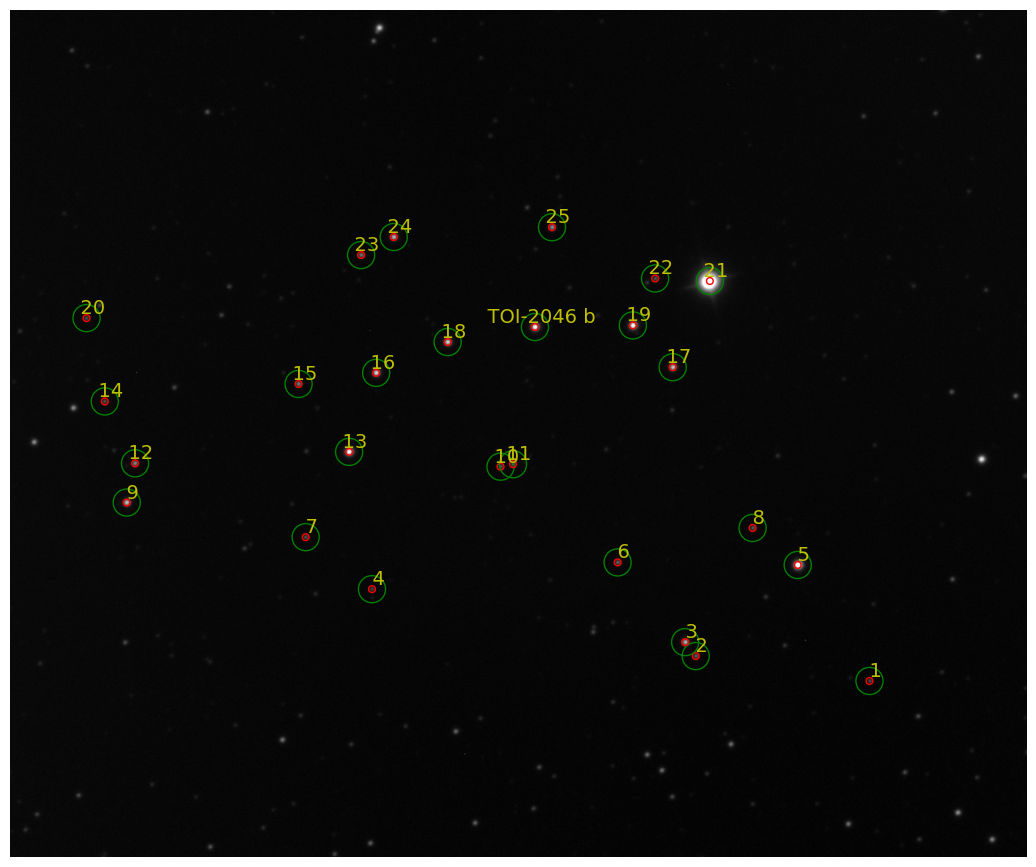

In [10]:
# Narisimo obmocja na prvo sliko. Ostale slike smo poravnali glede na prvo sliko in bi morale imeti zvezde na istih pozicijah.
image_data = fits.getdata(os.path.join(folder, "LIGHT", "TOI-2046 b", "V_45.00_0000.fits.reduced.aligned"))
plt.figure(figsize = (14, 11))
plt.imshow(image_data, vmin = 120, vmax = 3000, cmap = 'gray', norm="log")


plt.xlim(1000,2500)
plt.ylim(550,1800)


finder = DAOStarFinder(fwhm=2.0, threshold=69.0)
sources = finder(image_data)  # Opomba: kličemo ga direktno, ne z .find()
x_border, y_border = (1100, 2300), (800, 1600)
viable = []
if sources is None or len(sources) == 0:
    print("⚠️ OPOZORILO: Na sliki ni bilo najdenih zvezd!")
else:
    print(f"✅ Število najdenih zvezd na sliki: {len(sources)}")
    
    # Prikažemo prvih 10 najdenih zvezd
    # Opomba: V novejših različicah so stolpci poimenovani 'x_centroid' in 'y_centroid'
    x_col = 'x_centroid' if 'x_centroid' in sources.colnames else 'xcentroid'
    y_col = 'y_centroid' if 'y_centroid' in sources.colnames else 'ycentroid'
    flux_col = 'flux'
    
    temp = 0
    for i in range(len(sources)):
        if  x_border[0] < sources[x_col][i] < x_border[1] and y_border[0] < sources[y_col][i] < y_border[1]:
                #print(f"  {temp:2d}: x={sources[x_col][i]:7.1f}, y={sources[y_col][i]:7.1f}, "
                #f"flux={sources[flux_col][i]:8.1f}")
                viable.append(i)
                temp +=1
#TOI naj bo na 1. mestu
toi_pos_in_list = 18
viable = [viable[toi_pos_in_list]] + viable[:toi_pos_in_list] + viable[toi_pos_in_list + 1:]

for n, i in enumerate(viable):
    cx, cy = sources["x_centroid"][i], sources['y_centroid'][i]
    #cx=stars[star][0]
    #cy=stars[star][1]
    if n == 0:
        star = "TOI-2046 b"
    else:
        star = str(n)
    # apertura
    circle = plt.Circle((cx, cy), 5, color='r', fill=False)
    plt.gca().add_patch(circle)

    # notranji radij kolobarja
    circle = plt.Circle((cx, cy), 20, color='g', fill=False)
    plt.gca().add_patch(circle)

    # tekst z oznako zvezde
    plt.text(cx, cy, '  '+ star, ha='center', va='bottom', c='y', fontsize=14)
    print(f"  {star}:\tx={cx},\ty={cy}")
plt.axis('off')

(np.float64(1000.0), np.float64(2500.0), np.float64(550.0), np.float64(1800.0))

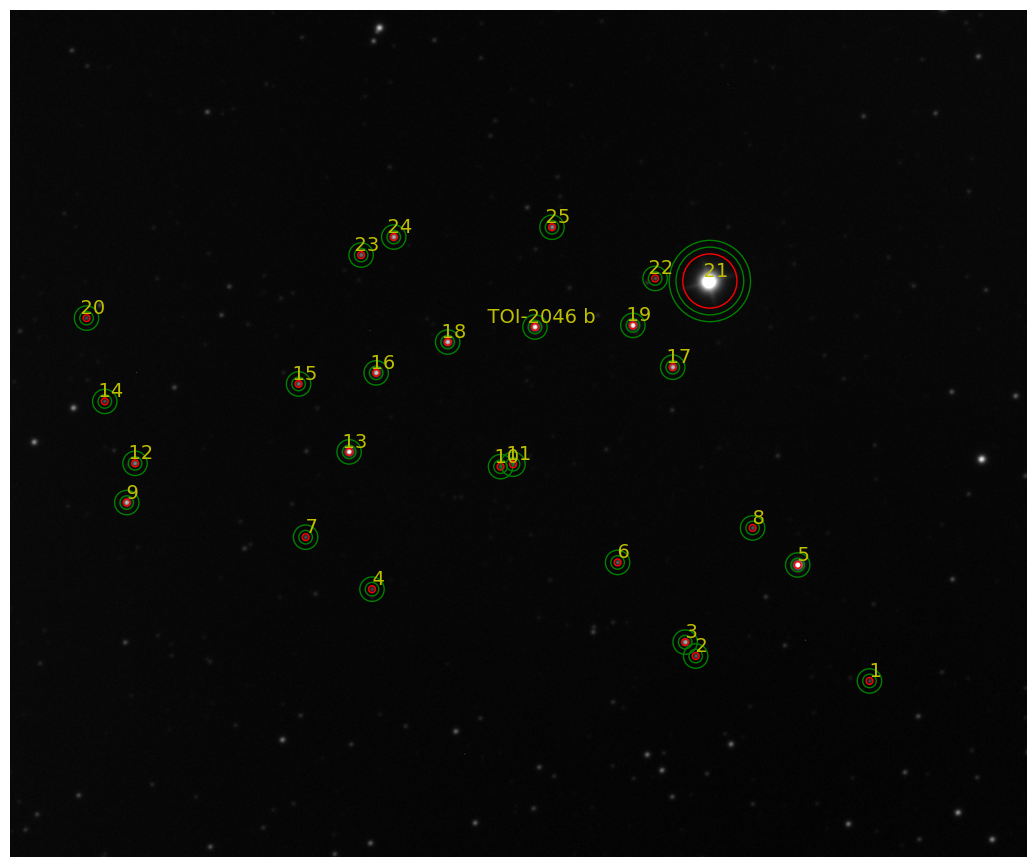

In [5]:
# Definirajmo obmocje (radij) znotraj katerega merimo signal zvezde
#aperture = 5.0

# Definirajmo notranji in zunanji radij kolobarja znotraj katerega merimo signal ozadja
#ring_inner = 10.0
#ring_outer = 18.0

# Narisimo obmocja na prvo sliko. Ostale slike smo poravnali glede na prvo sliko in bi morale imeti zvezde na istih pozicijah.
image_data = fits.getdata(os.path.join(folder, "LIGHT", "TOI-2046 b", "V_45.00_0000.fits.reduced.aligned"))
plt.figure(figsize = (14, 11))
plt.imshow(image_data, vmin = 120, vmax = 3000, cmap = 'gray', norm="log")


plt.xlim(1000,2500)
plt.ylim(550,1800)

#TUKAJ bi  vpisali stars


for star in stars.keys():
    cx=stars[star][0]
    cy=stars[star][1]
    # apertura
    circle = plt.Circle((cx, cy), stars[star][3][0], color='r', fill=False)
    plt.gca().add_patch(circle)

    # notranji radij kolobarja
    circle = plt.Circle((cx, cy), stars[star][3][1], color='g', fill=False)
    plt.gca().add_patch(circle)

    # zunanji radij kolobarja
    circle = plt.Circle((cx, cy), stars[star][3][2], color='g', fill=False)
    plt.gca().add_patch(circle)

    # tekst z oznako zvezde
    plt.text(cx, cy, '  '+ str(star), ha='center', va='bottom', c='y', fontsize=14)

plt.axis("off")

Sedaj lahko izmerimo signal v pikslih znotraj definiranih apertur in kolobarjev. Najprej moramo najti piksle, ki ležijo znotraj apertur in kolobarjev. V tem primeru bodo to vsi piksli katerih center leži znotraj aperture ali kolobarja. Če bi bili bolj pedantni, bi lahko signal pikslov na robu območij skalirali glede na delež piksla, ki leži znotraj območja.

Tako kot v vaji Robna zatemnitev Sonca bomo izdelali matriko, ki ima velikost slike in vsak element podaja oddaljenost piksla od centra, ki definira koordinato zvezde. Piksle, ki ležijo v koncentričnih območjih lahko potem enostavno izberemo brez da bi rabili na vsakem posnetku za vsak piksel poiskati oddaljenost od centra zvezde. Matrike, ki imajo vrednost 0 za piksle, ki ne ležijo v pravem območju in 1 za piksle, ki ležijo znotraj aperture ali kolobarja dodamo v naš slovar lastnosti zvezd.

Vse imamo pripravljeno, da na vseh posnetkih zvezdnega polja izmerimo svetlost izbranih zvezd. Ker nas zanima spreminjanje svetlosti v času, bomo rezultate shranili v tabelo. Ena tabela naj vsebuje čase in druga tabela izmerjene signale.

Signal pikslov, ki so znotraj aperture, seštejemo. Za signal pikslov, ki so znotraj kolobarja pa izračunamo mediano. Tako dobimo povprečen signal ozadja enega piksla, ki pa ni močno prizadet zaradi morebitne vključitve kake zvezde v kolobar. Če se je to zgodilo, zvezda pokvari signal le v manjšem delu pikslov in  ne vpliva na mediano. Od signala seštetega po pikslih znotraj aperture odštejemo signal ozadja, ki pa ga moramo pomnožiti s številom pikslov v aperturi. 

In [6]:
# Definirajmo matriko (isto velik okot sliko), ki oznacuje piksle, ki so znotraj radija aperture 
# in matriko za piksle, ki so znotraj kolobarja.
# To naredimo za vse zvezde, k inas zanimajo. Matrike dodamo v zgornji slovar.
# Dodamo se stevilo pikslov, ki so znotraj radija aperture.
image_data = fits.getdata(os.path.join(folder, "LIGHT", "TOI-2046 b", "V_45.00_0000.fits.reduced.aligned"))

for star in stars.keys():
    cx=stars[star][0]
    cy=stars[star][1]
    # tabela oddaljenosti od centra zvezde
    y, x = np.indices(image_data.shape)
    r = np.sqrt((x - cx)**2 + (y - cy)**2)
    
    # piksli, ki so znotraj aperture:
    labels_aperture = np.zeros(image_data.shape, dtype=int)
    labels_aperture[(r < stars[star][3][0])]=1
    # stevilo pikslov znotraj aperture
    n_pixels=np.sum(labels_aperture)

    # piksli, ki so znotraj kolobarja
    labels_ring = np.zeros(image_data.shape, dtype=int)
    labels_ring[(r < stars[star][3][2])&(r > stars[star][3][1])]=1

    # dodajmo vse to v slovar
    stars[star].append(labels_aperture)
    stars[star].append(labels_ring)
    stars[star].append(n_pixels)

if True:
    try:
        del circle
    except: pass
    del cx
    del cy
    del y
    del x
    del r
    del labels_aperture
    del labels_ring
    del n_pixels

    
    
# seznam vseh slik
images = glob.glob(os.path.join(folder, "LIGHT", "TOI-2046 b", "*.fits.reduced.aligned"))

# prostor za shranjevanje rezultatov
date = []
signal = []

negotovost = []

# zanka po vseh slikah
for image in images:
    # odpremo posnetek
    image_data, header = fits.getdata(image, header=True)
    time_obs = header['DATE-AVG']

    # sem shranimo signale izmerjene za vse zvezde na enem posnetku
    signals = []
    
    negotovosti = []

    # izracunamo signal znotraj aperture in kolobarja za vsako zvezdo
    for star in stars.keys():
        labels_aperture = stars[star][4]
        labels_ring = stars[star][5]
        n_pixels = stars[star][6]

        brightness_aperture = np.sum(image_data[labels_aperture==1])
        brightness_ring_per_pixel = np.median(image_data[labels_ring==1])

        signal_star = brightness_aperture - brightness_ring_per_pixel * n_pixels
        
        signals.append(signal_star)
        
        
        
        #seštevek kvadratov napak: dN = sqrt(dN^2 + d(N_ozadje * n_px)^2)
        negotovosti.append(np.sqrt(brightness_aperture + brightness_ring_per_pixel * n_pixels))

    # shranimo datum/cas
    date.append(time_obs)
    # v prvo tabelo shranimo tabelo signalov vseh zvezd na tem posnetku
    signal.append(signals)
    negotovost.append(negotovosti)
    


# spremenimo sezname z rezultati v numpy array, ker je z njimi lazje delat
date=np.array(date)
signal=np.array(signal)
negotovost = np.array(negotovost)

Narišimo rezultate. Najprej narišimo svetlost zvezde HAT-P-32. Signal, ki predstavlja svetlobni tok bomo preračunali v magnitude. Tabelo s časi, ki sedaj podaja čas kot string pa bomo morali prevest v format, ki je razumljiv modulom, ki jih uporabljamo za risanje grafov in analizo podatkov. 

Vidimo, da je svetlobna krivulja zelo kaotična. Nobene sledi ni o signalu prehoda planeta. Razlog, da magnituda postaja tekom opazovanja temnejša je, da je zvezda zahajala in je zato vedno več svetlobe absorbirala atmosfera. Ob tem se je tudi slabšalo vreme, kar je dodatno potemnilo zvezdo. Spremenljivo vreme vidimo kot občasne padce svetlosti, ko je zvezdo zakril kak manjši oblak. Dva vertikalna skoka svetlosti sta umetna in se zgodita, kjer se je spremenil ekspozicijski čas. Daljši ekspozicijski čas pomeni več zbrane svetlobe, močnejši signal in posledično nižjo magnitudo. 

Narišimo še svetlobno krivuljo za vse primerjalne zvezde. Pričakujemo, da bodo imele podobno obliko, saj so bile takisto prizadete zaradi atmosferske absorpcije, vremena in spremembe ekspozicijskega časa.

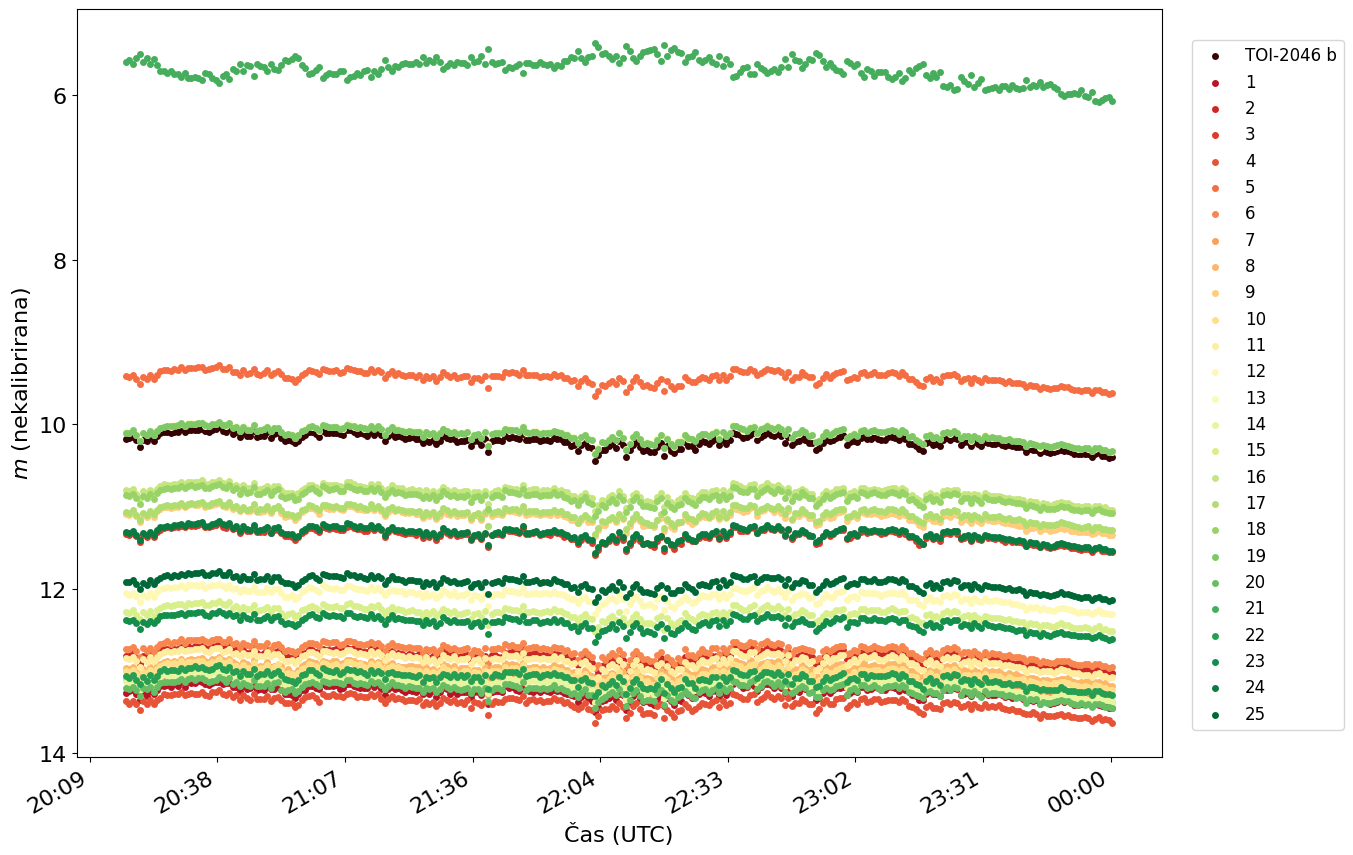

In [7]:
# prevedimo seznam datumov in casov v format, ki ga bo lahko prebral matplotlib
# uporabimo knjiznico astropy in prevedimo format casa
date_dt = Time(date)
plt.figure(figsize = (14, 11))

# Preracunajmo signale v magnitude
# Izbira izhodisca je poljubna
zero_point = 1e9
signal_mag = -2.5 * np.log10(signal/zero_point)
negotovost_mag = negotovost/signal

# Narisimo magnitudo zvezde HAT-P-32
# date_dt.plot_date vrne cas, ki je razumljiv matplotlibu
#plt.scatter(date_dt.plot_date, signal_mag[:,0], s = 4, lw = 0)
#plt.errorbar(date_dt.plot_date, signal_mag[:,0], negotovost_mag[:,0], fmt="o")


# Narisimo magnitudo primerjalnih zvezd
for i, label_key in zip(range(len(stars)), stars.keys()):
    plt.scatter(date_dt.plot_date, signal_mag[:,i], s = 4, lw = 3, label = label_key, c= c_map[label_key])


plt.xlabel('Čas (UTC)', fontsize=16)
plt.ylabel('$m$ (nekalibrirana)', fontsize=16)
# Vecja stevilka za magnitudo pomeni temnejso zvezdo. Dajmo zato obrnit y skalo tako, da nizje pomeni temneje in visje svetleje
plt.gca().invert_yaxis()

plt.legend( bbox_to_anchor=(1.02, 0.97), fontsize = 12)

# Polepsajmo format zapisa datuma z uro in minutami
fmt = mdates.DateFormatter("%H:%M")
plt.gca().xaxis.set_major_formatter(fmt)
plt.gca().tick_params(labelsize=16)
plt.gcf().autofmt_xdate()

Iz znanih magnitud teh primerjalnih zvezd in s predpostavko, da je njihova magnituda konstanta, lahko izračunamo popravke, ki bodo kompenzirali vse telurične hibe našega opazovanja. Narišimo najprej popravke in raziščimo ali so konsistentni za vse primerjalne zvezde. Popravek enostavno izračunamo kot razliko med izmerjeno in znano magnitudo.

2026-05-07T20:17:48.824 2026-05-08T00:00:20.624


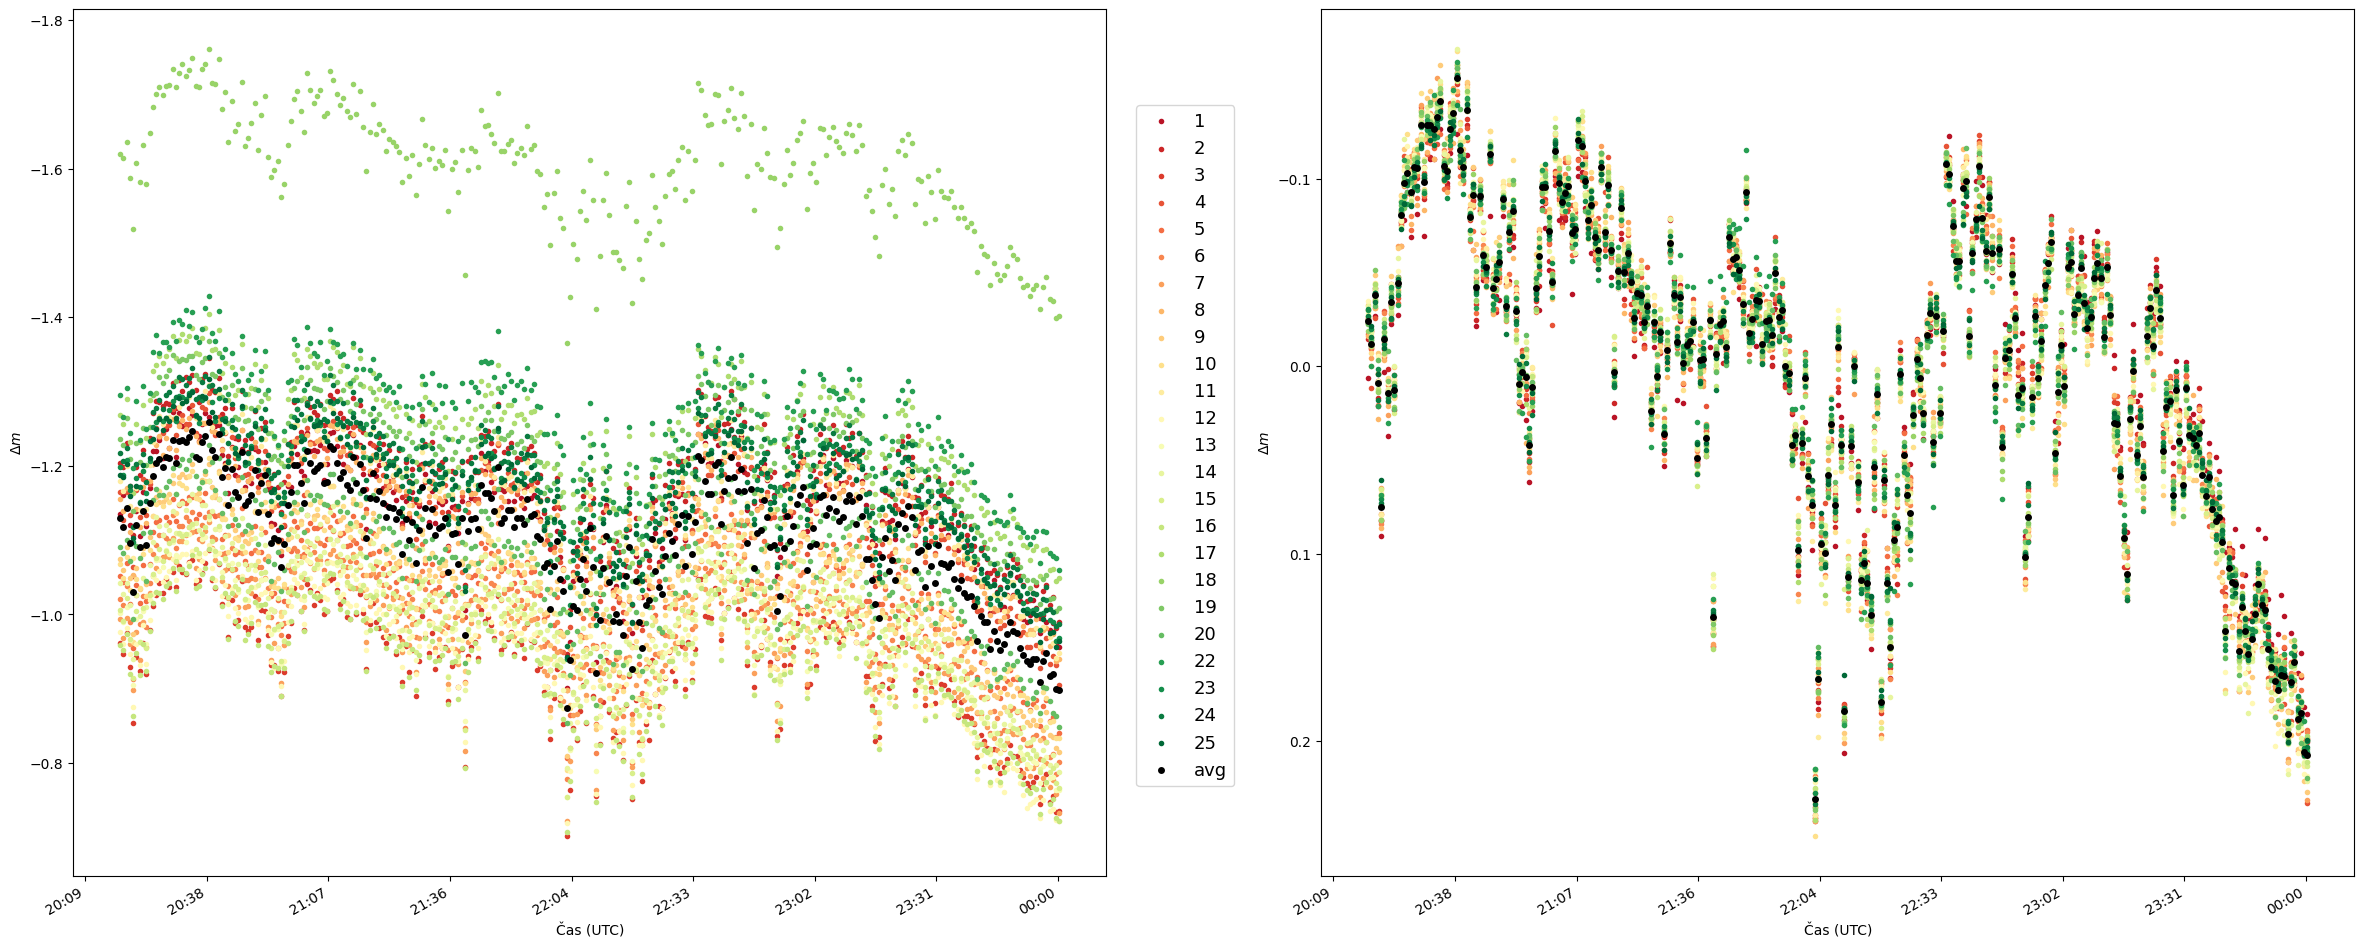

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(24, 10))
#plt.figure(figsize=(12, 10))
# Izracunamo normalizacijo preko znane magnitude primerjalnih zvezd
corr = []
for i in stars.keys():
    if i == "TOI-2046 b" or i == 21: pass
    else:
        corr.append(signal_mag[:,i] - stars[i][2])
        # Narisimo popravke
        #plt.scatter(date_dt.plot_date, signal_mag[:,i] - stars[i][2], s = 4, lw = 2, label = i, c= c_map[i])
        ax[0].scatter(date_dt.plot_date, signal_mag[:,i] - stars[i][2], s = 4, lw = 2, label = i, c= c_map[i])
        ax[1].scatter(date_dt.plot_date, signal_mag[:,i] - stars[i][2] - np.average(signal_mag[:,i] - stars[i][2]), s = 4, lw = 2, label = i, c= c_map[i])


corr = np.array(corr)
correction = np.average(corr, axis=0)

# Narisimo se povprecje popravkov
#plt.scatter(date_dt.plot_date, correction, s = 4, lw = 3, c = 'k', label = 'avg')
#plt.xlabel('Čas (UTC)', fontsize=16)
#plt.ylabel('$\\Delta m$', fontsize=16)
ax[0].scatter(date_dt.plot_date, correction, s = 4, lw = 3, c = 'k', label = 'avg')
ax[0].set_xlabel('Čas (UTC)')
ax[0].set_ylabel('$\\Delta m$')

ax[1].scatter(date_dt.plot_date, correction - np.average(correction), s = 4, lw = 3, c = 'k', label = 'avg')
ax[1].set_xlabel('Čas (UTC)')
ax[1].set_ylabel('$\\Delta m$')

ax[0].legend( bbox_to_anchor=(1.02, 0.9), fontsize = 13)
#plt.legend( bbox_to_anchor=(1.02, 1.04), fontsize = 16)
'''plt.gca()
plt.gca()
plt.gcf()'''
print(date_dt[0], date_dt[-1])

ax[0].invert_yaxis()
ax[0].xaxis.set_major_formatter(fmt)
ax[1].invert_yaxis()
ax[1].xaxis.set_major_formatter(fmt)
fig.autofmt_xdate()
fig.tight_layout(pad = 2)

#plt.gca().invert_yaxis()
#plt.gca().xaxis.set_major_formatter(fmt)
#plt.gca().tick_params(labelsize=16)
#plt.gcf().autofmt_xdate()

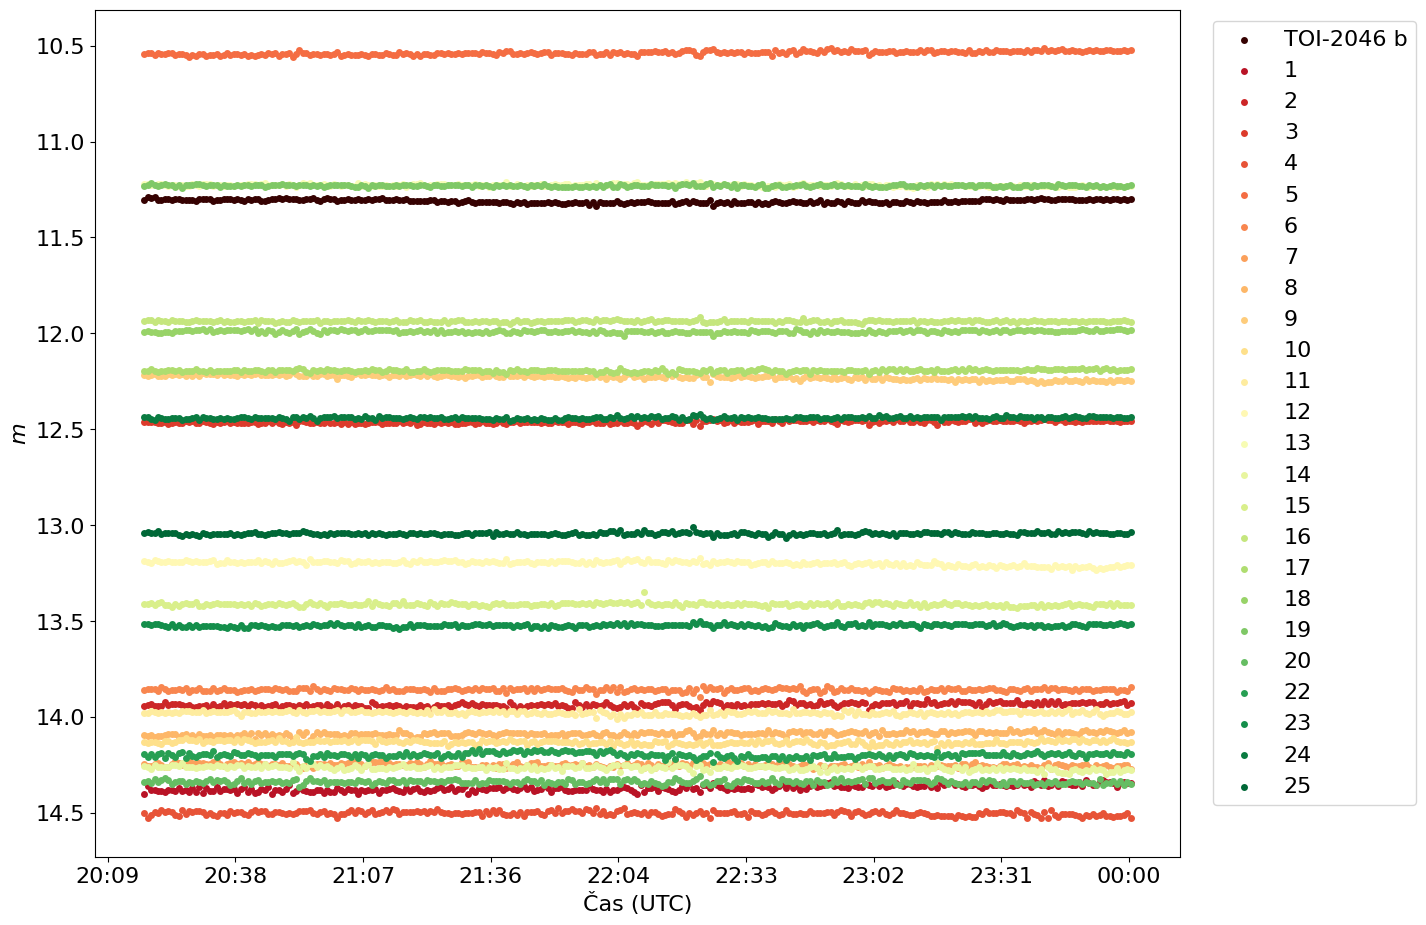

In [9]:
plt.figure(figsize = (14, 11))


# Narisimo magnitudo primerjalnih zvezd
for i, label_key in zip(range(len(stars)), stars.keys()):
    if label_key != 21:
        plt.scatter(date_dt.plot_date, signal_mag[:,i] - correction, s = 4, lw = 3, label = label_key, c= c_map[label_key])
plt.xlabel('Čas (UTC)', fontsize=16)
plt.ylabel('$m$', fontsize=16)
plt.gca().invert_yaxis()
plt.gca().xaxis.set_major_formatter(fmt)
plt.gca().tick_params(labelsize=16)
plt.legend( bbox_to_anchor=(1.02, 1), fontsize = 16)

Komentar: zvezda označena z 21 ima nestabilno magnitudo tudi po popravku.  
Smiselno bi bilo mogoče jo izključiti iz obdelave popravka

Magnitudo zvezde HAT-P-32 lahko popravimo, tako da od njene izmerjene magnitude odštejemo popravek, ki smo ga izračunali iz magnitude primerjalnih zvezd. 

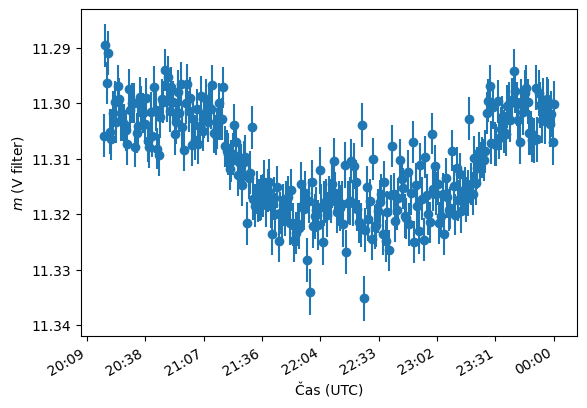

In [10]:
# Narisimo magnitudo zvezde HAT-P-32 z odstetim popravkom
plt.scatter(date_dt.plot_date, signal_mag[:,0] - correction, s = 8, lw = 0)
plt.errorbar(date_dt.plot_date, signal_mag[:,0] - correction, negotovost_mag[:,0], fmt="o")
plt.xlabel('Čas (UTC)')
plt.ylabel('$m$ (V filter)')

plt.gca().invert_yaxis()


plt.gca().xaxis.set_major_formatter(fmt)
plt.gcf().autofmt_xdate()

Lepo vidimo padec svetlosti, ki se začne okoli časa 16:50. Zaradi manj natančne fotometrije je konec prehoda slabše opazen. Zgodi se okoli časa 19:50. 

### Modeliranje svetlobne krivulje

Iz izmerjene svetlobne krivulje lahko izračunamo razmerje med velikostjo planeta in zvezde ter razmerje med veliko polosjo orbite planeta in velikostjo zvezde. Prvo smo pokazali že v uvodu, slednje pa ob predpostavki krožnih orbit poravnanih z ravnino opazovalca dobimo iz razmerja obhodnega časa in trajanja prehoda:
$$ \Delta t =\frac{P}{2\pi a} 2 R,$$
kjer je $\Delta t$ čas trajanja prehoda, $P$ perioda, ki jo izmerimo iz daljših opazovanj (torej čas med dvema prehodoma), $a$ je velika polos orbite planeta, $R$ pa je radij zvezde.

Na obliko svetlobne krivulje vpliva še čas, ko planet zakriva le rob zvezde. To v svetlobni krivulji vidimo kot počasno padanje in naraščanje sija na levi in desni strani minimuma svetlosti. Koliko časa ta faza traja in kakšna je oblika padanja in naraščanja sija je odvisno od velikosti zvezde in planeta ter od oblike orbite. Predvsem je pomembna še inklinacija orbite, saj ni nujno da planet prečka središče zvezdne ploskvice.

Če je planet na ekscentrični eliptični orbiti na čas trajanja prehoda vpliva še orientacija orbite. Bližje zvezde se planet giblje hitreje, dlje od je pa počasneje. Del orbite, ki leži med nami in zvezdo ima hitrost nekje med obema tema skrajnostima. 

Ko cela ploskvica planeta prekriva ploskvico zvezde, je količina zastrte svetlobe odvisna tudi od površinske svetlosti zvezde, ki jo podaja funkcija robne zatemnitve. To vidimo kot spreminjanje minimuma svetlobne krivulje v obliki črke U. Iz tega lahko izmerimo robno zatemnitev, ali pa predpostavimo model robne zatemnitve, s čimer lažje ocenimo inklinacijo orbite planeta. 

Našteli smo nekaj parametrov, ki vplivajo na obliko svetlobne krivulje. V praksi jih ne merimo neposredno iz časov prehoda in globin svetlobne krivulje, ampak izdelamo model krivulje, ki ga prilagajamo na naše meritve. Fizika kompletnega modela je preprosta, geometrija pa ne. Geometrija je izpeljana v članku [K. Mandel & E. Agol: *_Analytic Light Curves for Planetary Transit Searches_*, AJ, 580, 2 (2002)](https://ui.adsabs.harvard.edu/abs/2002ApJ...580L.171M/abstract). Model iz tega članka lahko v pythonu narišemo z modulom <tt>batman</tt>, zato se tukaj ne bomo poglabljali v analitično obliko svetlobne krivulje.

Z modulom <tt>batman</tt> lahko izdelamo model svetlobne krivulje, ki jo pričakujemo pri danih parametrih. V spodnjem primeru uporabim podatke iz literature, raze nsrednjega časa prehoda, ki sem ga nastavil glede na čas izmerjen iz našega opazovanja. Vidimo, da naša meritev le ni tako slaba in lepo sledi modelu iz literature. Poigrajte se s parametri modela in raziščite kako vplivajo na obliko svetlobne krivulje.

[Vir za podatke](https://arxiv.org/pdf/2205.01860)

[Parent link](https://arxiv.org/abs/2205.01860)  


[Drug vir](https://iopscience.iop.org/article/10.3847/1538-3881/ae0f19/pdf)

[Parent link](https://ui.adsabs.harvard.edu/abs/2025AJ....170..341S/abstract)

	mag_0		t_0		r_p/R_z		a/R_z		inc_orb		ecc_orb		d_periastrona		u		u1		u2		
lin	11.3018	61167.9	0.118676	4.69465	83.6087	0	88.0179	0.596226					
quad	11.3018	61167.9	0.118676	4.69465	83.6087	0	88.0179			0.596226	0	
log	11.3017	61167.9	0.120761	4.74938	83.6001	0	88.0083			0.599989	4.11755e-05	
exp	11.3016	61167.9	0.121001	4.74957	83.6001	0	87.9783			0.599975	7.23102e-05	
................................................................................................................................................................
δ lin	3.37979e-05	1.7082e-07	0.0504552	9.31978	0.0694126			34.0546	0.35612					
δ quad	3.38028e-05	1.80328e-07	0.0857402	9.41165	0.0729899			35.2613			1.5462			
δ log	3.33886e-05	1.78135e-07	0.0905623	9.21377	0.0676287			39.4411			2.2539	48677	
δ exp	3.33858e-05	2.01944e-07	0.154896	9.00734	0.0661805			77.6343			1.14608	4741.52	
.........................................................................................................................................

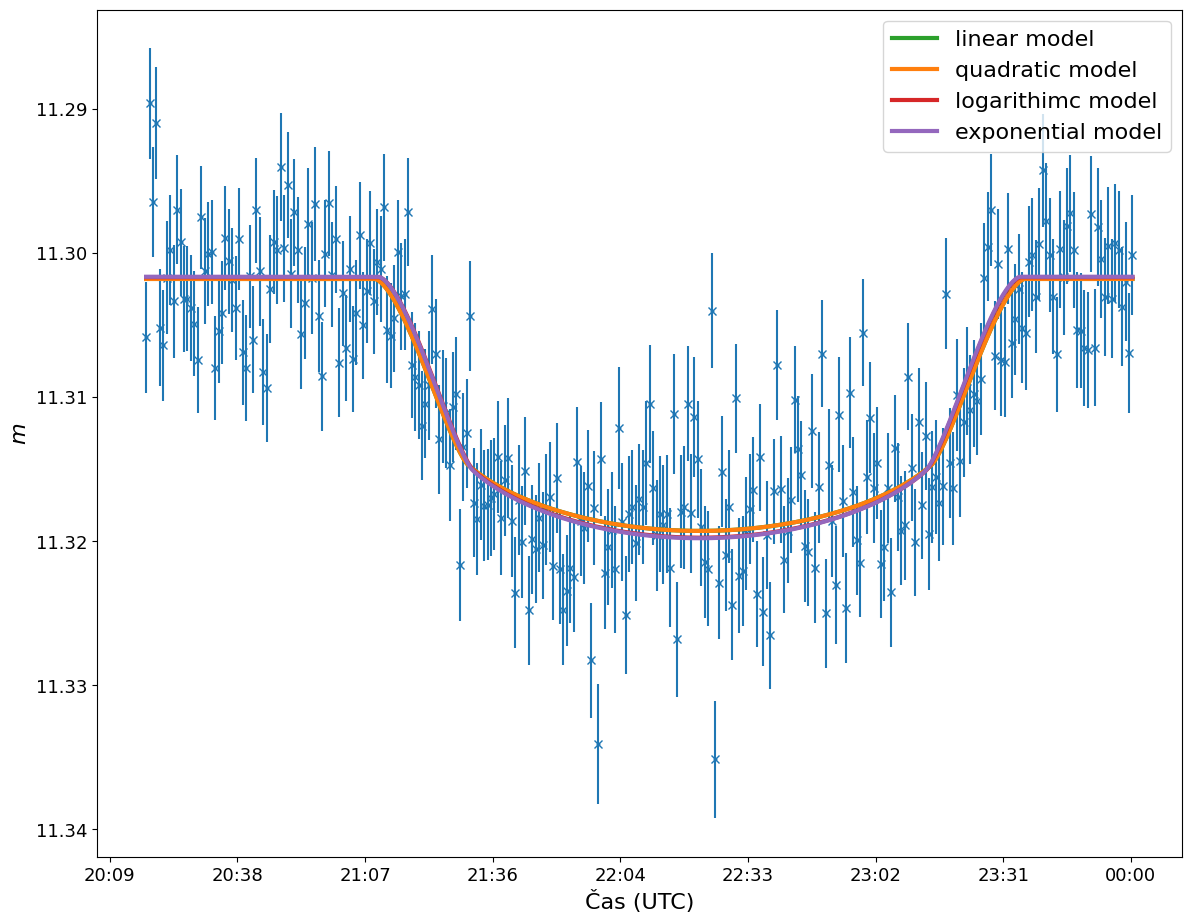

In [11]:
# Narisimo se enkrat naso svetlobno krivuljo. 
# Enote na x osi naj bodo tokrat decimalni dnevi, saj v taki obliki model svetlobne krivulje sproducira batman
plt.figure(figsize = (14, 11))
plt.scatter(date_dt.mjd, signal_mag[:,0] - correction, s=8, lw=0)
plt.errorbar(date_dt.mjd, signal_mag[:,0] - correction, negotovost_mag[:,0], fmt="x")
plt.xlabel('Čas (UTC)', fontsize=16)
plt.ylabel('$m$', fontsize=16)
plt.gca().invert_yaxis()
plt.gca().xaxis.set_major_formatter(fmt)
plt.gca().tick_params(labelsize=13)



'''# Naredimo objekt, v katerem so zapisani parametri planeta, zvezde in orbite
params = batman.TransitParams()

# V objekt dodamo parametere
params.t0 =     6.116793e4                   # cas sredine prehoda v decimalnih dnevih   23:56
params.per =    1.4971842                   # orbitalna perioda v decimalnih dnevih  3.51
params.rp =     0.1213                       # radij planeta v enotah radija zvezde (razmerje r/R)
params.a =      4.75                          # velika polos orbite planeta v enotah radija zvezde (razmerje a/R)
params.inc =    83.6                        # inklinacija orbite planeta v stopinjah (90 stopinj pomeni poravnano z Zemljo)
params.ecc =    0.0                         # ekscentricnost orbite planeta
params.w =      88.0                          # dolzina periastrona v stopinjah
params.u =     [0.6]                         # koeficient robne zatemnitve (ali vec koeficientov, ce ne uporabimo linearnega modela)
params.limb_dark = "linear"              # model robne zatemnitve

# Definiramo obmocje casov v katerih bomo narisali model
t = np.linspace(min(date_dt.mjd), max(date_dt.mjd), 100)

# izracunamo model
m = batman.TransitModel(params, t)
# modeliran svetlobni tok prepisemo v novo spremenljivko
#flux = m.light_curve(params)


m_0 = 11.30
# prevedimo svetlobni tok v magnitude
# umeritev dodamo sami, saj model ne ve kako svetlo zvezdo smo opazovali
mag_model=-2.5*np.log10(flux) + m_0'''

def lin_model(x, m0, t0, rp, a, inc, ecc, w, u):
    # Naredimo objekt, v katerem so zapisani parametri planeta, zvezde in orbite
    params = batman.TransitParams()
    # V objekt dodamo parametere
    params.t0, params.rp, params.a, params.inc, params.ecc, params.w, params.u = t0, rp, a, inc, ecc, w, [u]
    params.per = 1.4971842
    params.limb_dark = "linear"

    return m0 -2.5 * np.log10(batman.TransitModel(params, x).light_curve(params))

def quad_model(x, m0, t0, rp, a, inc, ecc, w, u1, u2):
    # Naredimo objekt, v katerem so zapisani parametri planeta, zvezde in orbite
    params = batman.TransitParams()
    # V objekt dodamo parametere
    params.t0, params.rp, params.a, params.inc, params.ecc, params.w, params.u = t0, rp, a, inc, ecc, w, [u1, u2]       
    params.per = 1.4971842        
    params.limb_dark = "quadratic"

    return m0 -2.5 * np.log10(batman.TransitModel(params, x).light_curve(params))

# Definiramo obmocje casov v katerih bomo narisali model
t = np.linspace(min(date_dt.mjd), max(date_dt.mjd), 1000)


            #m0     t0          rp          a        inc        ecc         w           u
init_guess = [11.3, 6.116793e4 , 0.1213    ,4.75      ,83.6      ,0.0       ,88.0      ,0.6,  0.0]
bounds = ([11.0, min(date_dt.mjd),  0,        0,       0,         0,         0,         0,    0],
          [11.5, max(date_dt.mjd), 10,    10000,     180,         10,        360,       1,    1])






popt, pcov = curve_fit(quad_model, date_dt.mjd ,signal_mag[:,0] - correction,
                       sigma= negotovost_mag[:,0], absolute_sigma=True, method="dogbox",
                       p0= init_guess,  bounds=bounds,
                       maxfev=100000000000000000)
#LIN FIT
#m0_fit, t0_fit, rp_fit, a_fit, inc_fit, ecc_fit, w_fit, u_fit = popt
#nm0_fit, nt0_fit, nrp_fit, na_fit, ninc_fit, necc_fit, nw_fit, nu_fit = np.sqrt(np.diag(pcov))
#QUAD FIT
m0_fit_quad, t0_fit_quad, rp_fit_quad, a_fit_quad, inc_fit_quad, ecc_fit_quad, w_fit_quad, u1_fit_quad, u2_fit_quad = popt
nm0_fit_quad, nt0_fit_quad, nrp_fit_quad, na_fit_quad, ninc_fit_quad, necc_fit_quad, nw_fit_quad, nu1_fit_quad, nu2_fit_quad = np.sqrt(np.diag(pcov))
quad_mag_model = quad_model(t, m0_fit_quad, t0_fit_quad, rp_fit_quad, a_fit_quad, inc_fit_quad, ecc_fit_quad, w_fit_quad, u1_fit_quad, u2_fit_quad)


popt, pcov = curve_fit(lin_model, date_dt.mjd ,signal_mag[:,0] - correction,
                       sigma= negotovost_mag[:,0], absolute_sigma=True, method="dogbox",
                       p0= init_guess[:-1],  bounds=(bounds[0][:-1], bounds[1][:-1]),
                       maxfev=100000000000000000)
#LIN FIT
m0_fit_lin, t0_fit_lin, rp_fit_lin, a_fit_lin, inc_fit_lin, ecc_fit_lin, w_fit_lin, u_fit_lin = popt
nm0_fit_lin, nt0_fit_lin, nrp_fit_lin, na_fit_lin, ninc_fit_lin, necc_fit_lin, nw_fit_lin, nu_fit_lin = np.sqrt(np.diag(pcov))
lin_mag_model = lin_model(t, m0_fit_lin, t0_fit_lin, rp_fit_lin, a_fit_lin, inc_fit_lin, ecc_fit_lin, w_fit_lin, u_fit_lin)

'''plt.plot(t,
    quad_model(np.linspace(min(date_dt.mjd), max(date_dt.mjd), 100),
               m0_fit_quad, t0_fit_quad, rp_fit_quad, a_fit_quad, inc_fit_quad, ecc_fit_quad, w_fit_quad, u1_fit_quad, u2_fit_quad),
    c='C1', label= "quadratic model")
plt.plot(t,
    lin_model(np.linspace(min(date_dt.mjd), max(date_dt.mjd), 100),
               m0_fit, t0_fit, rp_fit, a_fit, inc_fit, ecc_fit, w_fit, u_fit),
    c='C2', label= "linear model")'''






def log_model(x, m0, t0, rp, a, inc, ecc, w, u1, u2):
    # Naredimo objekt, v katerem so zapisani parametri planeta, zvezde in orbite
    params = batman.TransitParams()
    # V objekt dodamo parametere
    params.t0, params.rp, params.a, params.inc, params.ecc, params.w, params.u = t0, rp, a, inc, ecc, w, [u1, u2]       
    params.per = 1.4971842        
    params.limb_dark = "logarithmic"

    return m0 -2.5 * np.log10(batman.TransitModel(params, x).light_curve(params))

popt, pcov = curve_fit(log_model, date_dt.mjd ,signal_mag[:,0] - correction,
                       sigma= negotovost_mag[:,0], absolute_sigma=True, method="dogbox",
                       p0= init_guess,  bounds=bounds,
                       maxfev=100000000000000000)
#LIN FIT
m0_fit_log, t0_fit_log, rp_fit_log, a_fit_log, inc_fit_log, ecc_fit_log, w_fit_log, u1_fit_log, u2_fit_log = popt
nm0_fit_log, nt0_fit_log, nrp_fit_log, na_fit_log, ninc_fit_log, necc_fit_log, nw_fit_log, nu1_fit_log, nu2_fit_log = np.sqrt(np.diag(pcov))
log_mag_model = log_model(t, m0_fit_log, t0_fit_log, rp_fit_log, a_fit_log, inc_fit_log, ecc_fit_log, w_fit_log, u1_fit_log, u2_fit_log)


def exp_model(x, m0, t0, rp, a, inc, ecc, w, u1, u2):
    # Naredimo objekt, v katerem so zapisani parametri planeta, zvezde in orbite
    params = batman.TransitParams()
    # V objekt dodamo parametere
    params.t0, params.rp, params.a, params.inc, params.ecc, params.w, params.u = t0, rp, a, inc, ecc, w, [u1, u2]       
    params.per = 1.4971842        
    params.limb_dark = "exponential"

    return m0 -2.5 * np.log10(batman.TransitModel(params, x).light_curve(params))

popt, pcov = curve_fit(exp_model, date_dt.mjd ,signal_mag[:,0] - correction,
                       sigma= negotovost_mag[:,0], absolute_sigma=True, method="dogbox",
                       p0= init_guess,  bounds=bounds,
                       maxfev=100000000000000000)
#LIN FIT
m0_fit_exp, t0_fit_exp, rp_fit_exp, a_fit_exp, inc_fit_exp, ecc_fit_exp, w_fit_exp, u1_fit_exp, u2_fit_exp = popt
nm0_fit_exp, nt0_fit_exp, nrp_fit_exp, na_fit_exp, ninc_fit_exp, necc_fit_exp, nw_fit_exp, nu1_fit_exp, nu2_fit_exp = np.sqrt(np.diag(pcov))
exp_mag_model = exp_model(t, m0_fit_exp, t0_fit_exp, rp_fit_exp, a_fit_exp, inc_fit_exp, ecc_fit_exp, w_fit_exp, u1_fit_exp, u2_fit_exp)




















plt.plot(t, lin_mag_model, label="linear model", c='C2', zorder= 4, lw = 3)
plt.plot(t, quad_mag_model, label="quadratic model", c='C1', zorder = 4, lw = 3)
plt.plot(t, log_mag_model, label="logarithimc model", c="C3", zorder = 4, lw = 3)
plt.plot(t, exp_mag_model, label="exponential model", c="C4", zorder=4, lw = 3)


plt.legend(fontsize=16)


print("\t", end="")
for j in ["mag_0", "t_0", "r_p/R_z", "a/R_z", "inc_orb", "ecc_orb", "d_periastrona", "u", "u1", "u2"]:
    print(f"{j}", end="\t\t")
print("")

for i in ["lin", "quad", "log", "exp"]:
    print(f"{i}", end="\t")
    for j in ["m0", "t0", "rp", "a", "inc", "ecc", "w", "u", "u1", "u2"]:
        try: print(f"{eval(f"{j}_fit_{i}"):.6g}", end="\t")
        except: print("\t", end="\t")
    print("", end="\n")

print("."*160)

for i in ["lin", "quad", "log", "exp"]:
    print(f"δ {i}", end="\t")
    for j in ["m0", "t0", "rp", "a", "inc", "ecc", "w", "u", "u1", "u2"]:
        try:
            if eval(f"{j}_fit_{i}") != 0:   print(f"{eval(f"(n{j}_fit_{i} / {j}_fit_{i})"):.6g}", end="\t")
            else: print(f"Δ: {eval(f"n{j}_fit_{i}"):.gg} ", end="\t")
        except: print("\t", end="\t")
    print("", end="\n")
    
print("."*160)

for i in ["lin", "quad", "log", "exp"]:
    print(f"Δ {i}", end="\t")
    for j in ["m0", "t0", "rp", "a", "inc", "ecc", "w", "u", "u1", "u2"]:
        try:
            print(f"{eval(f"n{j}_fit_{i}"):.6g}", end="\t")
        except: print("\t", end="\t")
    print("", end="\n")

Opomba: kvadratni model je enak linearnemu

## Vprašanja

 * Koliko mora biti velik kolobar, ki nam definira območje merjenja svetlosti neba v primerjavi z radijem, ki definira območje signala zvezde?
 * Kakšnemu razmerju svetlobnih tokov odgovarjata razliki magnitud $\Delta m=0.01$ in $\Delta m=0.001$?
 * Recimo, da smo opazovali prehod, ki pa se ni zgodila ob napovedanem času, ampak 15 minut prepozno. Kaj lahko sklepamo o takem tujem osončju?
 * Okoli zvezde HAT-P-32, ki ima magnitudo 11.2 kroži še pritlikavka tipa M, ki je 3.5 magnitude temnejša. Zvezd z našim teleskopom ne moremo razločit in ju na slikah vidimo kot en objekt. Kolikšen delež signala v našo aperturo prispeva pritlikavka tipa M?
 * V tej vaji nismo izračunali nedoločenosti naših meritev (magnitud zvezde ob vsakem času) pa bi jih morali. Kako bi izračunali nedoločenost?